# Notebook scope: 

We'll try to forecast the hourly solar energy forecast(Spain), entire year's forecast will be covered at once( Re-Train Freqquency: Yearly)
1. Re-use the data cleaning & imputation techniques used in previously.
2. We'll refit the STL + ARIMA(Residual) on solar energy data:2020-2024, no change in ARIMA model build on 2020-2023 trained.
3. We'll build the another state-space model (UnobservedComponents), try to tweak its parameters based on the performance evaluation.
4. Train Data: 2020-2024 , Test Data:2025 , Re-train frequency: Yearly

# Importing Basic Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [2]:
def load_and_prepare_energy_data(filepath: str):
    """
    Reads raw energy production dataset and returns cleaned
    solar, wind, and mixed DataFrames.

    Steps performed:
    - Parse Date and hour columns
    - Create hourly datetime index
    - Aggregate duplicate timestamps
    - Remove duplicates
    - Log transform Production
    - Split by Source
    """

    # 1️⃣ Read data
    df = pd.read_csv(
        filepath,
        dtype={
            "Date": "string",
            "Start_Hour": "int64",
            "End_Hour": "int64"
        }
    )

    # 2️⃣ Create datetime index
    df["start_datetime"] = (
        pd.to_datetime(df["Date"], format="%m/%d/%Y")
        + pd.to_timedelta(df["Start_Hour"], unit="h")
    )

    df = df.set_index("start_datetime")
    df = df.sort_index()

    # 3️⃣ Aggregate duplicate timestamps (hour-level)
    df["Production"] = (
        df["Production"]
        .groupby(level=0)
        .transform("sum")
    )

    # 4️⃣ Remove duplicates after aggregation
    df = df[~df.index.duplicated(keep="first")]

    # 5️⃣ Log transformation (handle zero safely)
    df["Production_ln"] = np.log1p(df["Production"])

    # 6️⃣ Split by source
    wind = df[df["Source"] == "Wind"].copy()
    solar = df[df["Source"] == "Solar"].copy()
    mixed = df[df["Source"] == "Mixed"].copy()

    return solar, wind, mixed

In [3]:
solar, wind, mixed = load_and_prepare_energy_data(
    "Energy Production Dataset.csv"
)

# Elementary Data Analysis

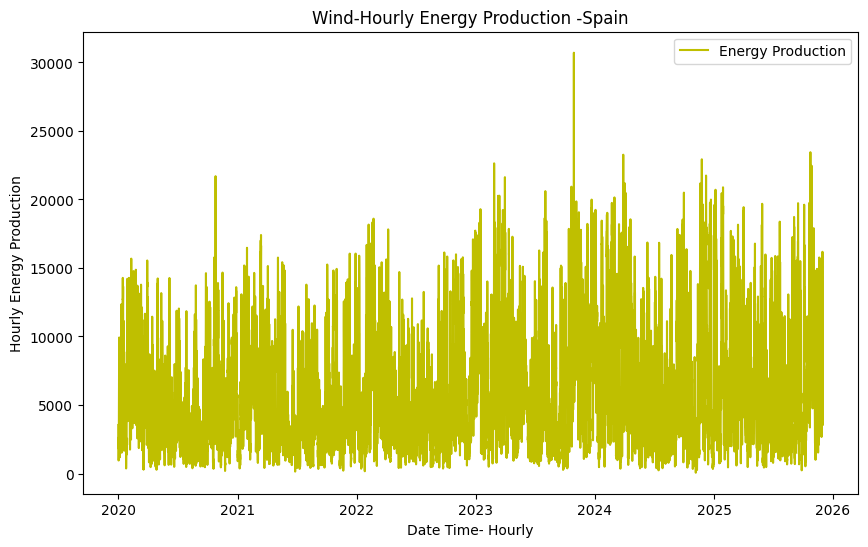

In [4]:
plt.figure(figsize=(10,6))
plt.plot(wind.index ,wind['Production'], color = 'y' ,label = 'Energy Production')
plt.xlabel('Date Time- Hourly')
plt.ylabel('Hourly Energy Production')
plt.title('Wind-Hourly Energy Production -Spain')
plt.legend(loc= 'best')
plt.show()

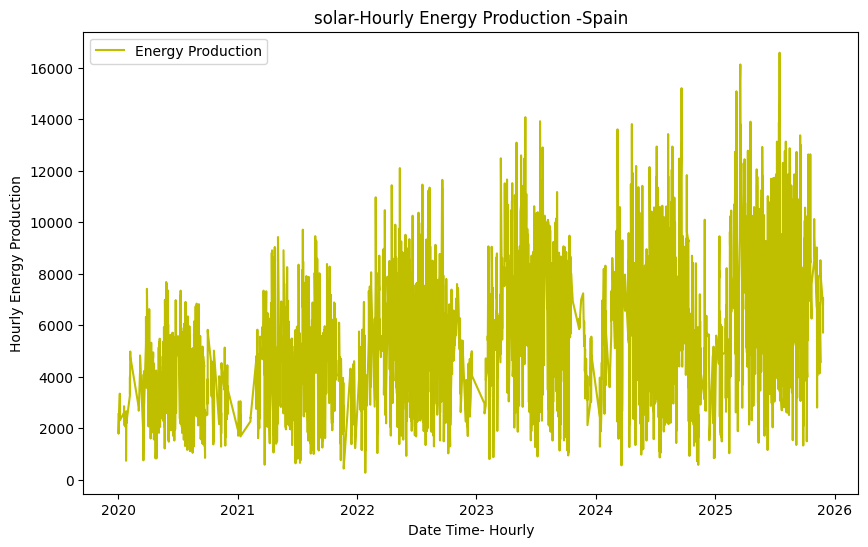

In [5]:
plt.figure(figsize=(10,6))
plt.plot(solar.index ,solar['Production'], color = 'y' ,label = 'Energy Production')
plt.xlabel('Date Time- Hourly')
plt.ylabel('Hourly Energy Production')
plt.title('solar-Hourly Energy Production -Spain')
plt.legend(loc= 'best')
plt.show()

Plot shows clear trend+ Multi Seasonality( Yearly, Monthly, Daily etc). Since seasonality also changes with increasing trend, hence we can conclude this
is multiplicative modelling scenario. We'll go ahead with modeling in log space making it a additive model

In [6]:
import plotly.graph_objects as go
def plot_monthly_production_interactive(df, source_name="Solar"):
    """
    Creates interactive monthly production plot with:
    - Year-wise traces
    - Season filter dropdown
    - Day filter dropdown
    
    Parameters
    ----------
    df : DataFrame (must contain index datetime + Production + Season + Day_Name + Month_Name)
    source_name : str (for title labeling)

    Returns
    -------
    fig : plotly.graph_objects.Figure
    """

    MONTH_ORDER = [
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ]

    def prepare_monthly(data, season=None, day_name=None):
        temp = data.copy()
        temp['year'] = temp.index.year

        if season is not None:
            temp = temp[temp['Season'] == season]

        if day_name is not None:
            temp = temp[temp['Day_Name'] == day_name]

        monthly = (
            temp
            .groupby(['year', 'Month_Name'], as_index=False)['Production']
            .sum()
        )

        monthly['Month_Name'] = pd.Categorical(
            monthly['Month_Name'],
            categories=MONTH_ORDER,
            ordered=True
        )

        return monthly


    fig = go.Figure()

    monthly = prepare_monthly(df)

    BASE_Y = []

    for year in sorted(monthly['year'].unique()):
        df_y = monthly[monthly['year'] == year]

        df_y = (
            df_y
            .set_index('Month_Name')
            .reindex(MONTH_ORDER)
            .reset_index()
        )

        BASE_Y.append(df_y['Production'])

        fig.add_trace(go.Scatter(
            x=df_y['Month_Name'],
            y=df_y['Production'],
            mode='markers',
            name=str(year),
            connectgaps=False
        ))


    # -----------------------
    # Season Buttons
    # -----------------------
    seasons = sorted(df['Season'].dropna().unique())

    season_buttons = [
        dict(
            label='All Seasons',
            method='update',
            args=[
                {'y': BASE_Y},
                {'title': f'Monthly {source_name} Production - All Seasons'}
            ]
        )
    ]

    for s in seasons:
        filtered = prepare_monthly(df, season=s)

        season_buttons.append(
            dict(
                label=s,
                method='update',
                args=[
                    {'y': [
                        (
                            filtered[filtered['year'] == int(t.name)]
                            .set_index('Month_Name')
                            .reindex(MONTH_ORDER)['Production']
                        )
                        for t in fig.data
                    ]},
                    {'title': f'Monthly {source_name} Production - {s}'}
                ]
            )
        )


    # -----------------------
    # Day Buttons
    # -----------------------
    days = sorted(df['Day_Name'].dropna().unique())

    day_buttons = [
        dict(
            label='All Days',
            method='update',
            args=[
                {'y': BASE_Y},
                {'title': f'Monthly {source_name} Production - All Days'}
            ]
        )
    ]

    for d in days:
        filtered = prepare_monthly(df, day_name=d)

        day_buttons.append(
            dict(
                label=d,
                method='update',
                args=[
                    {'y': [
                        (
                            filtered[filtered['year'] == int(t.name)]
                            .set_index('Month_Name')
                            .reindex(MONTH_ORDER)['Production']
                        )
                        for t in fig.data
                    ]},
                    {'title': f'Monthly {source_name} Production - {d}'}
                ]
            )
        )


    fig.update_layout(
        xaxis=dict(
            categoryorder='array',
            categoryarray=MONTH_ORDER
        ),
        updatemenus=[
            dict(buttons=season_buttons, x=1.05, y=1.35),
            dict(buttons=day_buttons, x=1.35, y=1.35),
        ],
        xaxis_title='Month',
        yaxis_title=f'{source_name} Production',
        title=f'Monthly {source_name} Production - All',
        hovermode='x unified'
    )

    return fig

In [7]:
fig = plot_monthly_production_interactive(solar, source_name="Solar")
fig.show()

###### EDA Observations:

1. Solar production missing at night hours.

2. Solar production missing at day hours as well for some days/year/month.

3. Solar production missing for entire 24 hours for some day.

Reason: might be because of cloudy day/data gathering issue/curtailment or  some other operational causes like capacity capping etc.

# Data Split- Train,Validation & Test

In [8]:
def time_series_train_val_test_split(
    df,
    train_end="2023-12-31",
    val_end="2024-12-31",
    freq="h"
):
    """
    Reindexes time series to full hourly index and performs
    strict chronological train/val/test split without overlap.
    """

    # Ensure datetime index sorted
    df = df.sort_index()

    # Create continuous hourly index
    full_idx = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq=freq
    )

    df_full = df.reindex(full_idx)

    # Define clean boundaries
    train_end_dt = pd.to_datetime(train_end) + pd.Timedelta(hours=23)
    val_end_dt   = pd.to_datetime(val_end) + pd.Timedelta(hours=23)

    train = df_full.loc[:train_end_dt].copy()
    val   = df_full.loc[train_end_dt + pd.Timedelta(hours=1):val_end_dt].copy()
    test  = df_full.loc[val_end_dt + pd.Timedelta(hours=1):].copy()

    # Mark observed
    for subset in (train, val, test):
        subset["_is_observed"] = subset["Production"].notna()

    return train, val, test

In [9]:
train, val, test = time_series_train_val_test_split(solar)

In [10]:
train = pd.concat([train, val])

# Data Imputation

## Creating Masks

In [11]:
## Daylight mask logic has been created with referece to the Spain-timezone/season
def create_daylight_mask(df: pd.DataFrame) -> pd.Series:
    """
    Returns a boolean Series indexed exactly like df.index
    indicating daylight hours for solar production (France).
    """

    # Extract once (no need to wrap again in Series)
    hour = df.index.hour
    month = df.index.month

    is_daylight = (
        (
            (((month <= 2) | (month == 12)) & (hour >= 9) & (hour <= 16))
            |
            ((month >= 3) & (month <= 4) & (hour >= 8) & (hour <= 18))
            |
            ((month >= 5) & (month <= 8) & (hour >= 7) & (hour <= 20))
            |
            ((month >= 9) & (month <= 10) & (hour >= 8) & (hour <= 18))
            |
            ((month == 11) & (hour >= 8) & (hour <= 17))
        )
    )

    # 🔒 HARD GUARANTEES
    is_daylight = pd.Series(is_daylight, index=df.index, dtype=bool)

    return is_daylight


In [12]:
def create_full_day_missing_mask(df:pd.DataFrame(), production_column:str = "Production") -> pd.Series():
    missing_days = (
    df[production_column]
    .isna()
    .groupby(train.index.date)
    .sum()
    )
    ## All 24 hours data missing
    missing_days = missing_days[missing_days == 24]
    # mask for full day missing (24hrs)
    is_full_day_missing = pd.Index(df.index.date).isin(missing_days.index)
    is_full_day_missing = pd.Series(
        is_full_day_missing,
        index=df.index
    )
    return is_full_day_missing

In [13]:
def impute_solar_hourly(
    df,
    hourly_weights,
    train_daily_climatology,
    production_col="Production",
):
    """
    Impute solar production with correct ordering:
    1. Full-day missing (daylight only) using TRAIN climatology
    2. Night hours → 0
    3. Partial-day daylight missing using same-day observed totals

    Parameters
    ----------
    df : pd.DataFrame
        Hourly solar dataframe (validation or test)
    hourly_weights : pd.Series
        Index = (month, hour), values sum to 1 per month (from TRAIN)
    train_daily_climatology : pd.Series
        Index = month, values = typical daily solar total (from TRAIN)- median_daily_by_month  Median profile by daily
    production_col : str
        Column name for solar production

    Returns
    -------
    df : pd.DataFrame
        Imputed dataframe (copy)
    """

    df = df.copy()
    is_daylight = create_daylight_mask(df)
    # ------------------------------------------------------------------
    # Precompute helpers
    # ------------------------------------------------------------------
    df["_date"] = df.index.date
    df["_month"] = df.index.month
    df["_hour"] = df.index.hour

    # ------------------------------------------------------------------
    # Identify full-day missing days (ALL 24 hours missing)
    # ------------------------------------------------------------------
    daily_missing_count = (
        df[production_col]
        .isna()
        .groupby(df["_date"])
        .sum()
    )

    full_missing_days = daily_missing_count[daily_missing_count == 24].index
    is_full_day_missing = df["_date"].isin(full_missing_days)

    # ------------------------------------------------------------------
    # STEP 1: Full-day missing → impute DAYLIGHT hours only
    # ------------------------------------------------------------------
    mask_full_day_daylight = (
        is_full_day_missing
        & is_daylight
        & df[production_col].isna()
    )

    if mask_full_day_daylight.any():
        # Map (month, hour) → hourly weight
        keys = list(zip(df.loc[mask_full_day_daylight, "_month"],
                        df.loc[mask_full_day_daylight, "_hour"]))
        df.loc[mask_full_day_daylight, "_hourly_weight"] = (
            pd.Series(keys, index=df.index[mask_full_day_daylight])
            .map(hourly_weights)
        )

        # Daily total from TRAIN climatology
        df.loc[mask_full_day_daylight, "_daily_total"] = (
            df.loc[mask_full_day_daylight, "_month"]
            .map(train_daily_climatology)
        )
        has_weight = df["_hourly_weight"].notna()
        df.loc[mask_full_day_daylight, production_col] = (
            df.loc[mask_full_day_daylight, "_hourly_weight"]
            * df.loc[mask_full_day_daylight, "_daily_total"]
        )

    # ------------------------------------------------------------------
    # STEP 2: Night hours → 0 (SAFE after step 1)
    # ------------------------------------------------------------------
    night_mask = (
    df[production_col].isna()
    & ~has_weight
    )
    
    df.loc[night_mask, production_col] = 0

    # ------------------------------------------------------------------
    # STEP 3: Partial-day daylight missing
    # ------------------------------------------------------------------
    mask_partial_daylight = (
        df[production_col].isna()
        & is_daylight
        & ~is_full_day_missing
    )

    if mask_partial_daylight.any():
        # Same-day observed daily total (after night zeroing)
        daily_totals = (
            df
            .groupby("_date")[production_col]
            .transform("sum")
        )

        keys = list(zip(df.loc[mask_partial_daylight, "_month"],
                        df.loc[mask_partial_daylight, "_hour"]))

        df.loc[mask_partial_daylight, "_hourly_weight"] = (
            pd.Series(keys, index=df.index[mask_partial_daylight])
            .map(hourly_weights)
        )

        df.loc[mask_partial_daylight, production_col] = (
            df.loc[mask_partial_daylight, "_hourly_weight"]
            * daily_totals.loc[mask_partial_daylight]
        )

    # ------------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------------
    df.drop(columns=[
        "_date", "_month", "_hour",
        "_hourly_weight", "_daily_total"
    ], errors="ignore", inplace=True)

    return df


In [14]:
def hourly_mapping(
    df: pd.DataFrame,
    hourly_weights: pd.Series,
    daily_forecast: pd.Series,
    production_col: str = "Production"
) -> pd.DataFrame:
    """
    Distribute daily forecast into hourly values using
    train-derived hourly weights with daily renormalization.
    """

    out = df.copy()

    # Time features
    out["_month"] = out.index.month
    out["_hour"] = out.index.hour
    out["_date"] = out.index.normalize()

    # Map daily forecast
    out["_daily_forecast"] = out["_date"].map(daily_forecast)

    # Hourly weight lookup (month, hour)
    out["_hourly_key"] = list(zip(out["_month"], out["_hour"]))
    out["_hourly_weight_raw"] = out["_hourly_key"].map(hourly_weights)

    # Daylight mask = weight exists
    daylight_mask = out["_hourly_weight_raw"].notna()

    # Renormalize weights per day
    weight_sum_per_day = (
        out.loc[daylight_mask]
        .groupby(out.loc[daylight_mask, "_date"])["_hourly_weight_raw"]
        .transform("sum")
    )

    out["_hourly_weight"] = 0.0
    out.loc[daylight_mask, "_hourly_weight"] = (
        out.loc[daylight_mask, "_hourly_weight_raw"] / weight_sum_per_day
    )

    # Allocate hourly forecast
    out["forecast_hourly"] = 0.0
    valid = out["_daily_forecast"].notna() & daylight_mask

    out.loc[valid, "forecast_hourly"] = (
        out.loc[valid, "_daily_forecast"]
        * out.loc[valid, "_hourly_weight"]
    )

    # Night hours explicitly zero
    out.loc[~daylight_mask, "forecast_hourly"] = 0.0

    return out

## Imputation on Train

### Seasonal Profile Creation

In [15]:
import pandas as pd

def compute_seasonal_profiles(train: pd.DataFrame,
                              production_col: str = "Production",
                              observed_col: str = "_is_observed"):
    """
    Compute seasonal production profiles from observed data only.

    Parameters
    ----------
    train : pd.DataFrame
        Time-indexed DataFrame (DatetimeIndex required).
    production_col : str
        Column containing production values.
    observed_col : str
        Boolean column indicating observed (non-imputed) data.

    Returns
    -------
    median_profile : pd.Series
        Median hourly production grouped by (month, hour).
        MultiIndex: (month, hour)

    median_daily_by_month : pd.Series
        Median daily total production grouped by month.
        Index: month (1–12)

    hourly_weights : pd.Series
        Normalized hourly weights within each month.
        MultiIndex: (month, hour)
    """

    if not isinstance(train.index, pd.DatetimeIndex):
        raise ValueError("train must have a DatetimeIndex")

    if production_col not in train.columns:
        raise ValueError(f"{production_col} not found in DataFrame")

    if observed_col not in train.columns:
        raise ValueError(f"{observed_col} not found in DataFrame")

    # Filter observed data
    is_observed = train[observed_col]
    observed_data = train.loc[is_observed]

    # 1️⃣ Median hourly profile (month, hour)
    median_profile = (
        observed_data
        .groupby([observed_data.index.month,
                  observed_data.index.hour])[production_col]
        .median()
    )

    # 2️⃣ Median daily totals by month
    observed_daily_totals = (
        observed_data
        .groupby(observed_data.index.normalize())[production_col]
        .sum()
    )

    median_daily_by_month = (
        observed_daily_totals
        .groupby(observed_daily_totals.index.month)
        .median()
    )

    # 3️⃣ Hourly weights within each month
    hourly_weights = (
        median_profile /
        median_profile.groupby(level=0).transform("sum")
    )

    return median_profile, median_daily_by_month, hourly_weights

In [16]:
median_profile, median_daily_by_month, hourly_weights = \
    compute_seasonal_profiles(train)

###  Imputing Train dataset

In [17]:
train_imputed = impute_solar_hourly(
    df = train,
    hourly_weights = hourly_weights,
    train_daily_climatology = median_daily_by_month,
    production_col="Production",
)

In [18]:
# Check If imuptation completed
train_imputed['Production'].isna().sum()

0

There are zero rows to be imputed now

In [19]:
# Cleaning imputed data and creating log space production column for imputed production
solar_cleaned = train_imputed[['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name',
       'Month_Name', 'Season', 'Production']].copy()
solar_cleaned['Production_ln'] = np.nan
mask = solar_cleaned['Production'] > 0

solar_cleaned.loc[mask, 'Production_ln'] = np.log(
    solar_cleaned.loc[mask, 'Production']
)

## Let us visualize train data before & after imputation

### Raw Scale- Before Imputation

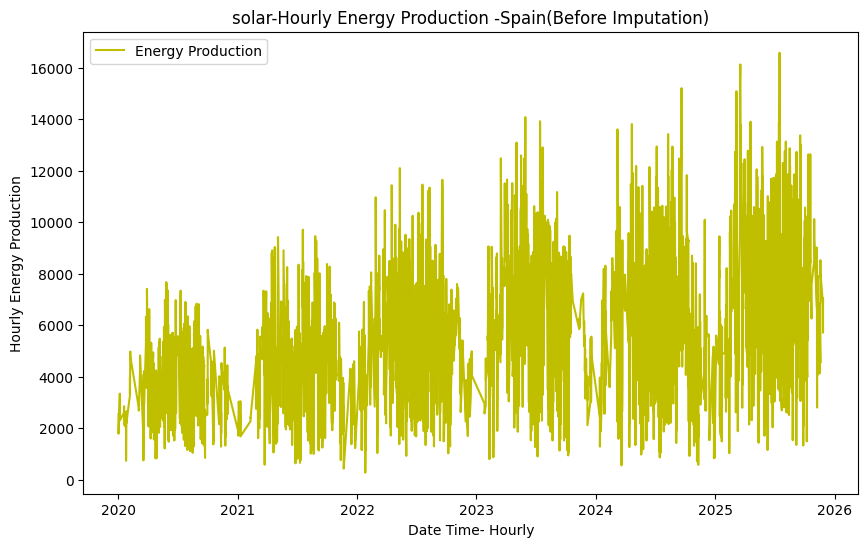

In [20]:
plt.figure(figsize=(10,6))
plt.plot(solar.index ,solar['Production'], color = 'y' ,label = 'Energy Production')
plt.xlabel('Date Time- Hourly')
plt.ylabel('Hourly Energy Production')
plt.title('solar-Hourly Energy Production -Spain(Before Imputation)')
plt.legend(loc= 'best')
plt.show()

### After Imputation

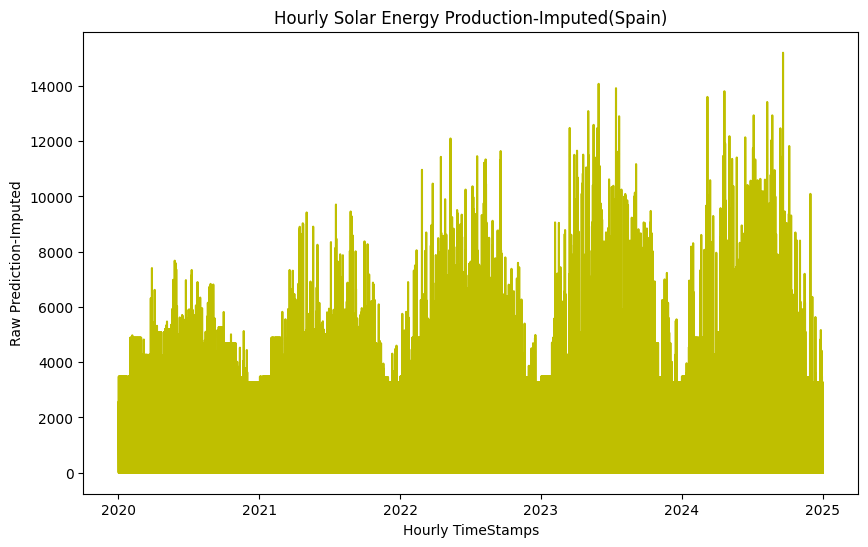

In [21]:
plt.figure(figsize=(10,6))
plt.plot(solar_cleaned.index,solar_cleaned.Production,color = 'y',label='Imputed Raw Prediction')
plt.xlabel('Hourly TimeStamps')
plt.ylabel('Raw Prediction-Imputed')
plt.title('Hourly Solar Energy Production-Imputed(Spain)')
plt.show()

### Log Scale- Before Imputation

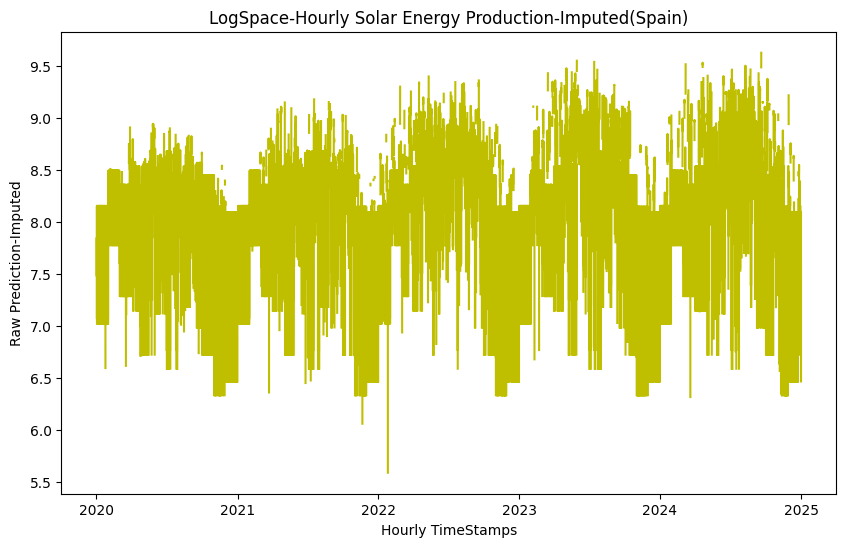

In [22]:
plt.figure(figsize=(10,6))
plt.plot(solar_cleaned.index,solar_cleaned.Production_ln,color = 'y',label='Log Space-Imputed Raw Prediction')
plt.xlabel('Hourly TimeStamps')
plt.ylabel('Raw Prediction-Imputed')
plt.title('LogSpace-Hourly Solar Energy Production-Imputed(Spain)')
plt.show()

### After Imputataion

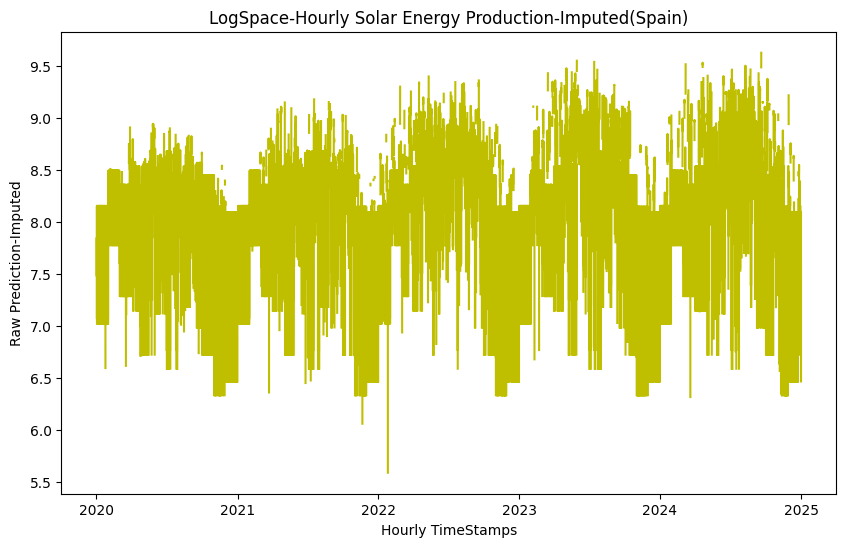

In [23]:
plt.figure(figsize=(10,6))
plt.plot(solar_cleaned.index,solar_cleaned.Production_ln,color = 'y',label='Log Space-Imputed Raw Prediction')
plt.xlabel('Hourly TimeStamps')
plt.ylabel('Raw Prediction-Imputed')
plt.title('LogSpace-Hourly Solar Energy Production-Imputed(Spain)')
plt.show()

## We will proceed for modelling in below order.

Step 1: Build daily solar series (daylight only)

Step 2: Log-transform daily series

Step 3: STL (yearly)

Step 4: ARIMA on remainder

Step 5: Forecast daily totals

Step 6: Redistribute using hourly profile

Step 7: Set night hours to zero

### Step 1: Build daily solar series (daylight only)

In [24]:
daily_solar = solar_cleaned.loc[solar_cleaned['Production'] > 0].groupby(pd.Grouper(freq='D'))['Production'].sum().to_frame(name = 'Solar_production')

### Step 2: Log-transform daily series

In [25]:
daily_solar['ln_Solar_production'] = np.log(
    daily_solar['Solar_production'].replace(0, np.nan)
)

#### Visualize Imputed Daily Solar Production- train data on original scale and Log scale

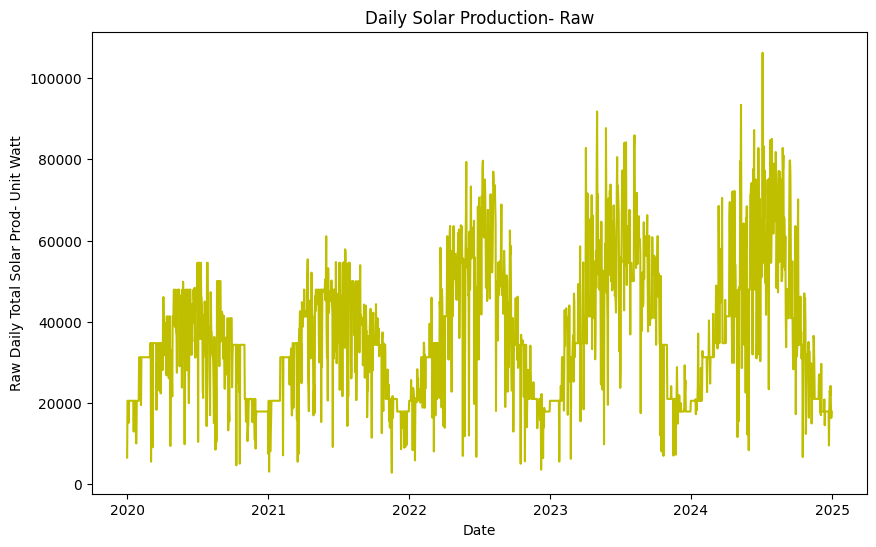

In [26]:
plt.figure(figsize=(10,6))
plt.plot(daily_solar.index,daily_solar['Solar_production'],color = 'y',label = 'Raw-Daily Total Solar Production')
plt.xlabel('Date')
plt.ylabel('Raw Daily Total Solar Prod- Unit Watt')
plt.title('Daily Solar Production- Raw')
plt.show()

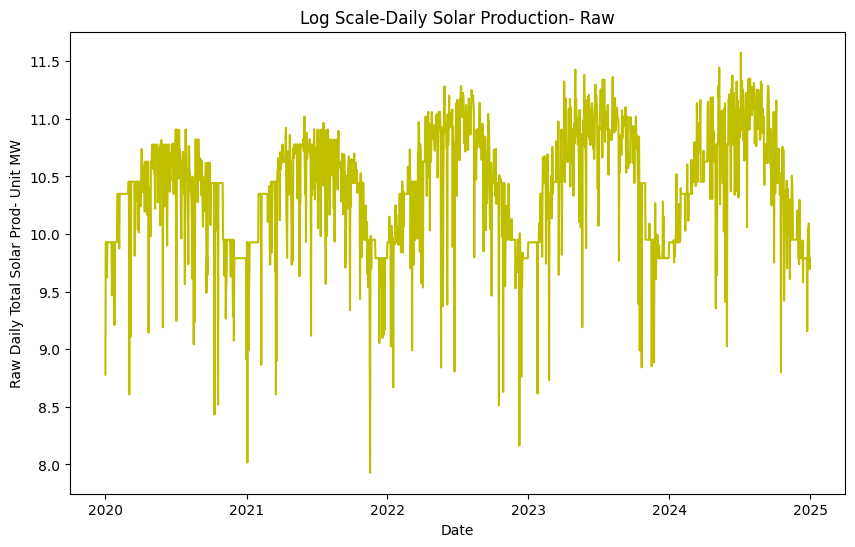

In [27]:
plt.figure(figsize=(10,6))
plt.plot(daily_solar.index,daily_solar['ln_Solar_production'],color = 'y',label = 'Log Scale-Daily Total Solar Production')
plt.xlabel('Date')
plt.ylabel('Raw Daily Total Solar Prod- Unit MW')
plt.title('Log Scale-Daily Solar Production- Raw')
plt.show()

### Step 3: STL (yearly)

In [28]:
from statsmodels.tsa.seasonal import STL

In [29]:
daily_solar = daily_solar.sort_index()
daily_solar = daily_solar.asfreq('D')

In [30]:
daily_solar.isna().sum()

Solar_production       0
ln_Solar_production    0
dtype: int64

No missing data found for daily total series

In [31]:
daily_solar[ daily_solar['ln_Solar_production'] < 0 ].sum() # There should be no -ve

Solar_production       0.0
ln_Solar_production    0.0
dtype: float64

There is no -ve solar production found , this is mendatory since we are modelling in log scale

#### STL Decomposition

In [32]:
daily_stl = STL(daily_solar.ln_Solar_production, period = 365, robust = True)
daily_stl_res = daily_stl.fit()

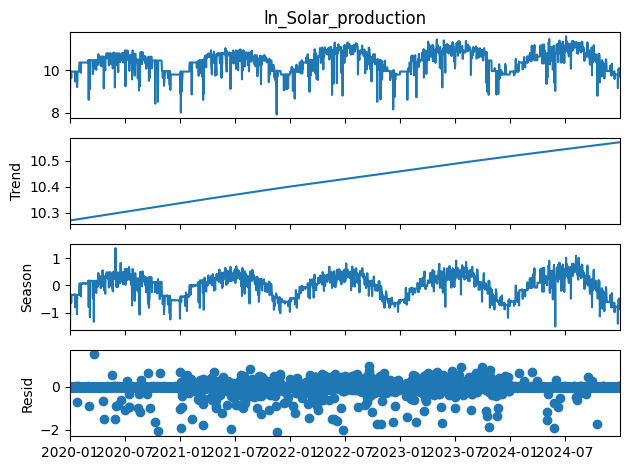

In [33]:
daily_stl_res.plot()
plt.show()

Trend Interpretaion: Monotonic updward growth might be because of installed capacity growth or efficieny imporovement

Season Interpretaion : 
Clear yearly oscilation.
Occasional peaks(downside/upside) may have occured due to sudden weather change or any operational reason 

Residual Interpretaion: No visible seasonality left. Mean ≈ 0 . Some outliers expected due to wweather extreme conditions

In [34]:
daily_solar['Trend']  = daily_stl_res.trend
daily_solar['Seasonal'] = daily_stl_res.seasonal
daily_solar['Residual'] = daily_stl_res.resid

In [35]:
train_seasonal_by_day = (
    daily_stl_res.seasonal
    .groupby(daily_stl_res.seasonal.index.dayofyear)
    .mean()
)

### Step 4: ARIMA on remainder

For modeling residual after STL decomposition, Stationarity check is mandatory. We'll proceed with ADFuller and KPSS test accordingly AR(p) & MA(q) 
p & q will be decided.

#### Stationarity check on Residual

#### ADFuller Test

In [36]:
from statsmodels.tsa.stattools import adfuller

In [37]:
adf_test = adfuller(daily_solar['Residual'].dropna())

In [38]:
adf_df = pd.DataFrame(data = np.column_stack([adf_test[0],adf_test[1],adf_test[4]]), columns=['ADF_Stats','p-Value','Critial_value'])

In [39]:
pd.set_option('display.max_colwidth', None)
adf_df.head()

,ADF_Stats,p-Value,Critial_value
0,-26.914587,0.0,"{'1%': -3.4339382310452033, '5%': -2.863125003847544, '10%': -2.56761380228936}"


In [40]:
adf_critical_level = pd.DataFrame(adf_test[4].items() ,columns=['Significance Level', 'Critical Value'] )
adf_critical_level

,Significance Level,Critical Value
0,1%,-3.433938
1,5%,-2.863125
2,10%,-2.567614


ADF Stats is lesser than all critical levels

p-Value<0.05 hence we can reject Ho:Non stationarity

#### KPSS Test

In [41]:
from statsmodels.tsa.stattools import kpss

In [42]:
kpss_res = kpss(daily_solar['Residual'].dropna(), nlags= 'auto' , regression= 'c')
kpss_critical_level = pd.DataFrame(kpss_res[3].items() ,columns=['Significance Level', 'Critical Value'] )
kpss_critical_level

,Significance Level,Critical Value
0,10%,0.347
1,5%,0.463
2,2.5%,0.574
3,1%,0.739


In [43]:
kpss_res_df = pd.DataFrame(data = np.column_stack([kpss_res[0],kpss_res[1]]),columns=['KPSS_STATS','p-Value'])
kpss_res_df

,KPSS_STATS,p-Value
0,0.583119,0.024171


p-Value > 0.05 Hence we fail to reject the Ho:Series is stationary

### ARIMA 

##### Selection of AR(p) , MA(q) and d

In [44]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

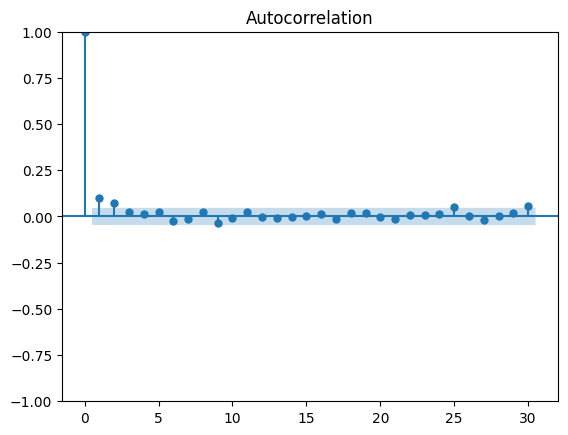

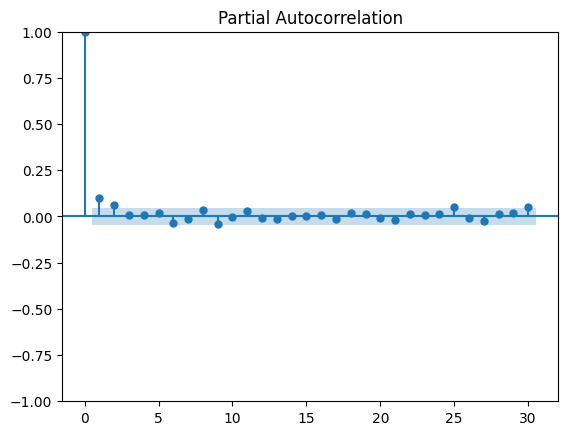

In [45]:
plot_acf(daily_solar["Residual"].dropna(), lags=30)
plot_pacf(daily_solar["Residual"].dropna(), lags=30)
plt.show()

ACF Interpretation : Lag0 is 1 which is expected, Lag = 1 and Lag = 2 and Lag=3 are above c.i. lag>3 is under the c.i. , hence short term memory exists
possibly MA(1) i.e. q=1

PACF Interpretation : Lag0 is 1 which is expected, Lag = 1 and Lag = 2  and Lag=3 are above c.i. lag>3 is under the c.i. , hence short term memory exists 
possiblye AR(1) i.e. p=1

Beyond Lag=3 all are noise.

In [46]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(daily_solar["Residual"].dropna(), lags=[7,14,30])

,lb_stat,lb_pvalue
7,31.712233,0.000046
14,36.619736,0.000842
30,52.163676,0.007313


#### Modelling ARIMA(1,0,1)

In [47]:
from statsmodels.tsa.arima.model import ARIMA

In [48]:
#p, d, q = 1, 0, 0
p, d, q = 1, 0, 1
arima_mod = ARIMA(daily_solar['Residual'],order=(p,d,q),enforce_invertibility=True,enforce_stationarity=True)
arima_res = arima_mod.fit()

In [49]:
arima_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               Residual   No. Observations:                 1827
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -488.436
Date:                Tue, 03 Mar 2026   AIC                            984.872
Time:                        19:06:04   BIC                           1006.914
Sample:                    01-01-2020   HQIC                           993.002
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0221      0.012     -1.817      0.069      -0.046       0.002
ar.L1          0.5459      0.153      3.570      0.000       0.246       0.846
ma.L1         -0.4476      0.161     -2.779      0.005      -0.763      -0.132
sigma2         0.0999      0.002     59.141      0.000       0.097       0.103
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):             12930.41
Prob(Q):                              0.84   Prob(JB):                         0.00
Heteroskedasticity (H):               0.77   Skew:                            -2.52
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [50]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(arima_res.resid, lags=[7,14,30])

,lb_stat,lb_pvalue
7,3.830392,0.799093
14,10.049832,0.758531
30,25.636228,0.693562


##### Model Summary
Ljung Box Test : 
Ho:Residuals are not autocorrelated upto K terms (i.e. white noise)
Prob(Q):0.53 > 0.05 Hence Fail to reject the Ho, hence no significance of autocorrelation this result confirms in ACF plot lag=2 spike(small) was misleading

ar.L1 & ma.L1 for both of these p-value<0.05 hence we can reject Ho: Constant=0. Lag 1 shows short term memory auto correlation

AIC = 593.069  , AIC=−2log(L)+2k
BIC	= 614.217    , BIC= -2log(L) + klog(n)

L = likelihood of the fitted model𝑘 ,
k = number of estimated parameters ,
n = number of observations

n=2161 , k =4 , L= -292.535

Heteroskedasticity (H): 0.91
Prob(H)               : 0.29
Underline Ho: Residual Variance constant over time (Homoskedastic) , p-value = 0.29> 0.05 hence fail to reject Ho. No need of variance modelling (GARCH)

##### Trying ARIMA (p,d,q) -> (2,0,2) based in ACF/PACF plot visuals

In [51]:
#p,d,q=1,0,1
p,d,q=2,0,2
arima_mod_2 = ARIMA(daily_solar['Residual'],order=(p,d,q),enforce_invertibility=True,enforce_stationarity=True)
arima_res2 = arima_mod_2.fit()

In [52]:
arima_res2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               Residual   No. Observations:                 1827
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -488.091
Date:                Tue, 03 Mar 2026   AIC                            988.183
Time:                        19:06:05   BIC                           1021.246
Sample:                    01-01-2020   HQIC                          1000.378
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0221      0.012     -1.835      0.066      -0.046       0.002
ar.L1          0.2716      1.115      0.244      0.808      -1.914       2.458
ar.L2          0.0623      0.665      0.094      0.925      -1.241       1.366
ma.L1         -0.1780      1.117     -0.159      0.873      -2.366       2.010
ma.L2         -0.0194      0.566     -0.034      0.973      -1.129       1.090
sigma2         0.0999      0.002     59.106      0.000       0.097       0.103
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             12931.31
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.77   Skew:                            -2.52
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [53]:
acorr_ljungbox(arima_res2.resid, lags=[7,14,30])

,lb_stat,lb_pvalue
7,3.189036,0.866981
14,9.645039,0.787648
30,25.536870,0.698545


##### Comparision

AIC and BIC both have increased in AR(2), MA(2) model and also all additional parameters are statistically insignificant

### Forecast

In [54]:
import numpy as np
import pandas as pd


def forecast_solar(
    df: pd.DataFrame,
    train_seasonal_by_day: pd.Series,
    arima_model,
    train_trend: pd.Series,
    production_col_name: str = "Production",
    mode: str = "forecast",  # "fit" or "forecast"
    bias_correct: bool = True,
) -> pd.DataFrame:
    """
    Daily solar forecast using:
    STL trend (extrapolated) + seasonal profile + ARIMA residual model.

    Parameters
    ----------
    df : pd.DataFrame
        Hourly dataframe (DatetimeIndex required)
    train_seasonal_by_day : pd.Series
        Seasonal component indexed by day-of-year (1–366)
    arima_model : fitted ARIMA results object
        ARIMA model trained on daily STL residual
    train_trend : pd.Series
        STL trend component from training period
    production_col_name : str
        Name of production column
    mode : str
        "fit" → use in-sample ARIMA fitted values
        "forecast" → use ARIMA forecast for horizon
    bias_correct : bool
        Apply log-normal bias correction

    Returns
    -------
    pd.DataFrame
        Daily dataframe with forecast components
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df must have DatetimeIndex")

    if mode not in ["fit", "forecast"]:
        raise ValueError("mode must be 'fit' or 'forecast'")

    df = df.copy()

    # ---- 1️⃣ Daily aggregation ----
    daily = (
        df.groupby(pd.Grouper(freq="D"))[production_col_name]
        .sum()
        .to_frame("Solar_production")
    )

    # ---- 2️⃣ Log transform safely ----
    daily["ln_Solar_production"] = np.nan
    mask = daily["Solar_production"] > 0
    daily.loc[mask, "ln_Solar_production"] = np.log(
        daily.loc[mask, "Solar_production"]
    )

    # ---- 3️⃣ Seasonal mapping ----
    daily["seasonal"] = daily.index.dayofyear.map(
        train_seasonal_by_day
    )

    # ---- 4️⃣ Residual component ----
    h = len(daily)

    if mode == "fit":
        resid_component = arima_model.fittedvalues
    else:
        resid_component = arima_model.forecast(steps=h)

    daily["arima_component"] = resid_component.values

    # ---- 5️⃣ Trend extrapolation ----
    last_trend = train_trend.iloc[-1]
    slope = train_trend.diff().median()

    trend_extrapolated = last_trend + slope * np.arange(1, h + 1)
    daily["trend"] = trend_extrapolated

    # ---- 6️⃣ Compose log forecast ----
    daily["ln_forecast"] = (
        daily["trend"].values
        + daily["seasonal"].values
        + daily["arima_component"].values
    )

    # ---- 7️⃣ Bias correction ----
    if bias_correct:
        sigma2 = arima_model.params.get("sigma2", 0)
        daily["forecast"] = np.exp(
            daily["ln_forecast"] + 0.5 * sigma2
        )
    else:
        daily["forecast"] = np.exp(daily["ln_forecast"])

    return daily

#### Forecast on Train dataset

In [55]:
daily_train = forecast_solar(
    df=train,
    train_seasonal_by_day=train_seasonal_by_day,
    arima_model=arima_res,
    train_trend=daily_stl_res.trend,
    mode="fit"
)

<Axes: >

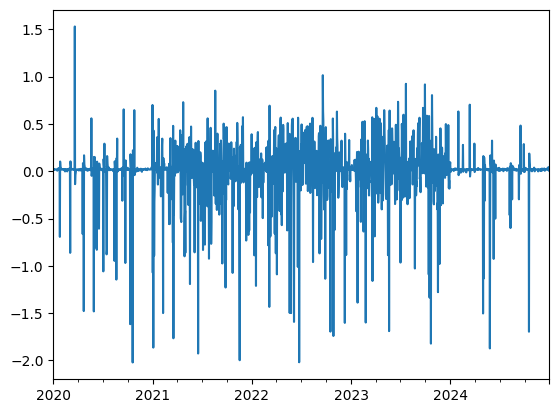

In [56]:
(arima_res.resid).plot()

<Axes: >

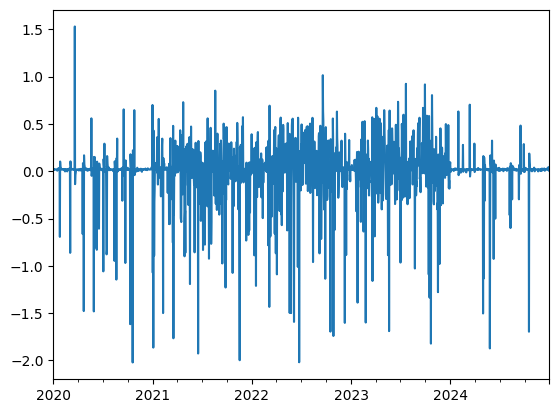

In [57]:
stl_resid = daily_stl_res.resid
arima_fit = arima_res.fittedvalues

(stl_resid - arima_fit).plot()

In [58]:
(stl_resid - arima_fit).mean()

9.244018064136903e-07

##### The series shows:

Strong variance during 2021–2023

Large negative spikes (~ -2)

Some positive spikes (~ +1.3)

Flat zero segments at edges (likely filtered low-production periods)

##### Interpretation:

1. Heteroskedasticity present
Variance is not constant over time. ARIMA assumes homoskedastic errors — this assumption is violated.

2. Outliers dominate error structure
    Those deep negative spikes are likely:
    
        Cloudy extreme days
        
        Curtailment
        
        Data quality issues
        
        Ramp failures

3. Model captures central tendency but not extremes
    Mean is near zero → good.
    Variance is large → tail behavior not modeled well.

. This is very close to zero, which indicates:

. No significant systematic bias

. ARIMA is not consistently over- or under-predicting the residual component

. Mean correction is essentially calibrated

### Conclusion

What This Implies for Solar Forecasting Framework

Given your workflow (seasonal median + ARIMA on residual):

    1. Seasonal structure is handled well.
    
    2. ARIMA is modeling smooth deviations.
    
    3. Extreme deviations remain unexplained noise.

In [59]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(stl_resid - arima_fit, lags=[7,14,30])

,lb_stat,lb_pvalue
7,3.830392,0.799093
14,10.049832,0.758531
30,25.636228,0.693562


In [60]:
(stl_resid - arima_fit).std()

0.31621709225767003

#### Forecast on Validation dataset

In [61]:
# Daily Forecast on validation dataset
daily_val = forecast_solar(
    df=val,
    train_seasonal_by_day=train_seasonal_by_day,
    arima_model=arima_res,
    train_trend=daily_stl_res.trend,
    mode="forecast"
)

In [62]:
## Daily Forecast on test dataset
daily_test = forecast_solar(
    df=test,
    train_seasonal_by_day=train_seasonal_by_day,
    arima_model=arima_res,
    train_trend=daily_stl_res.trend,
    mode="forecast"
)

## Forecast Evaluation

In [63]:
from sklearn.metrics import mean_absolute_percentage_error,mean_absolute_error,root_mean_squared_error

In [64]:
observed_val_mask = daily_val['Solar_production'] > 0
observed_test_mask = daily_test['Solar_production'] > 0

In [65]:
mape_daily_val = mean_absolute_percentage_error(daily_val.loc[observed_val_mask]['Solar_production'], daily_val.loc[observed_val_mask]['forecast'])
mape_daily_val

0.280044792766603

In [66]:
mape_daily_test = mean_absolute_percentage_error(daily_test.loc[observed_test_mask]['Solar_production'], daily_test.loc[observed_test_mask]['forecast'])
mape_daily_test

0.3994523365747419

In [67]:
mae_daily_val = mean_absolute_error(daily_val.loc[observed_val_mask]['Solar_production'], daily_val.loc[observed_val_mask]['forecast'])
mae_daily_val

9095.828793688559

In [68]:
mae_daily_test = mean_absolute_error(daily_test.loc[observed_test_mask]['Solar_production'], daily_test.loc[observed_test_mask]['forecast'])
mae_daily_test

18790.965150258056

In [69]:
rmse_daily_val =  root_mean_squared_error(daily_val.loc[observed_val_mask]['Solar_production'], daily_val.loc[observed_val_mask]['forecast'])
rmse_daily_val

12393.711483133276

In [70]:
rmse_daily_test =  root_mean_squared_error(daily_test.loc[observed_test_mask]['Solar_production'], daily_test.loc[observed_test_mask]['forecast'])
rmse_daily_test

23338.770065226938

## Bias Diagnosis

In [71]:
bias_val = (daily_val.loc[observed_val_mask]['forecast'] - daily_val.loc[observed_val_mask]['Solar_production']).mean()
bias_val

507.1158725168661

In [72]:
bias_test = (daily_test.loc[observed_test_mask]['forecast'] - daily_test.loc[observed_test_mask]['Solar_production']).mean()
bias_test

-8671.279056328214

In [73]:
bias_pct_val = bias_val / daily_val.loc[observed_val_mask]["Solar_production"].mean() * 100
bias_pct_val

1.0316934486406877

In [74]:
# Naya wala 2021-2024
bias_pct_test = bias_test / daily_test.loc[observed_test_mask]["Solar_production"].mean() * 100
bias_pct_test

-14.794729301523613

<Axes: title={'center': 'Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton'}, xlabel='Date', ylabel='Numerical Ratio'>

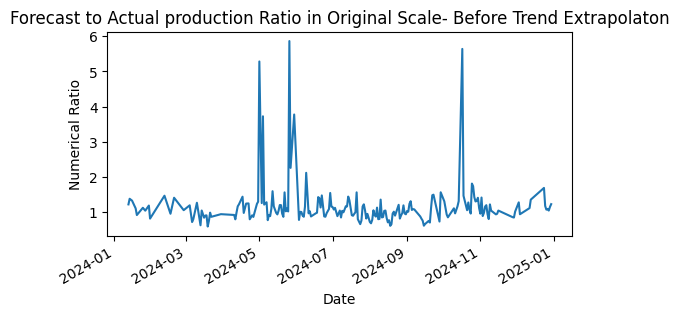

In [75]:
plt.figure(figsize=(6,3))
plt.xlabel('Date')
plt.ylabel('Numerical Ratio')
plt.title("Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton")
(daily_val.loc[observed_val_mask]["forecast"] / daily_val.loc[observed_val_mask]["Solar_production"]).plot()

Underforecast during high production months

<Axes: title={'center': 'Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton'}, xlabel='Date', ylabel='Numerical Ratio'>

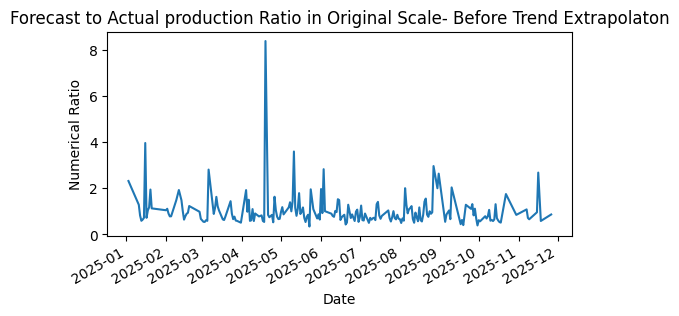

In [76]:
# # Naya wala 2021-2024
plt.figure(figsize=(6,3))
plt.xlabel('Date')
plt.ylabel('Numerical Ratio')
plt.title("Forecast to Actual production Ratio in Original Scale- Before Trend Extrapolaton")
(daily_test.loc[observed_test_mask]["forecast"] / daily_test.loc[observed_test_mask]["Solar_production"]).plot()

In [77]:
smape_val = np.mean(
    2 * np.abs(daily_val.loc[observed_val_mask]['forecast'] - daily_val.loc[observed_val_mask]['Solar_production']) / (np.abs(daily_val.loc[observed_val_mask]['forecast']) + np.abs(daily_val.loc[observed_val_mask]['Solar_production']))
)
smape_val

0.20750211209544664

In [78]:
smape_test = np.mean(
    2 * np.abs(daily_test.loc[observed_test_mask]['forecast'] - daily_test.loc[observed_test_mask]['Solar_production']) / (np.abs(daily_test.loc[observed_test_mask]['forecast']) + np.abs(daily_test.loc[observed_test_mask]['Solar_production']))
)
smape_test

0.3524087530138251

In [79]:
print("Validation Bias-> ",bias_val)
print("Validation Bias Percentage-> ",bias_pct_val)

Validation Bias->  507.1158725168661
Validation Bias Percentage->  1.0316934486406877


In [80]:
print("Test Bias-> ",bias_test)
print("Test Bias Percentage-> ",bias_pct_test)

Test Bias->  -8671.279056328214
Test Bias Percentage->  -14.794729301523613


[]

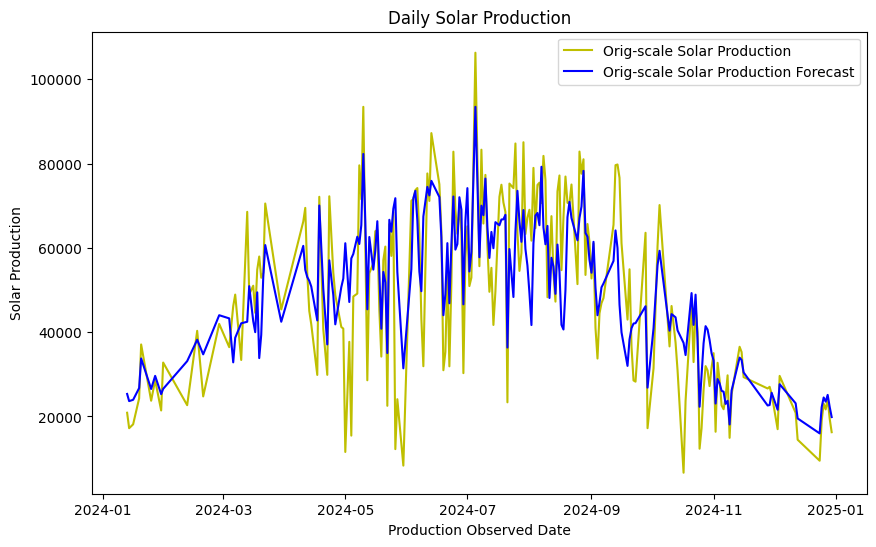

In [81]:
plt.figure(figsize=(10,6))
plt.plot(daily_val[observed_val_mask].index, daily_val[observed_val_mask]['Solar_production'] , color ='y' , label ='Orig-scale Solar Production')
plt.plot(daily_val[observed_val_mask].index, daily_val[observed_val_mask]['forecast'],  color ='b' , label ='Orig-scale Solar Production Forecast')
plt.xlabel('Production Observed Date')
plt.ylabel('Solar Production')
plt.title('Daily Solar Production')
plt.legend(loc= 'best')
plt.plot()

[]

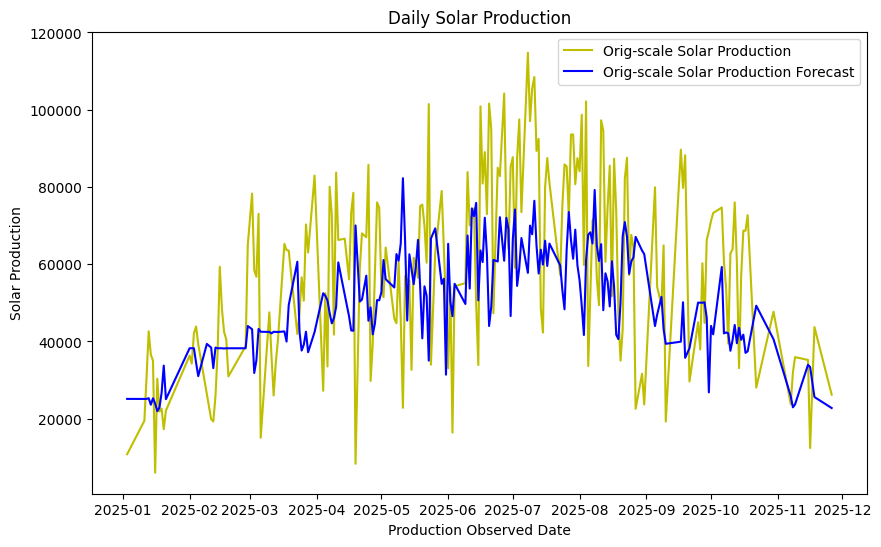

In [82]:
# # Naya wala 2021-2024
plt.figure(figsize=(10,6))
plt.plot(daily_test[observed_test_mask].index, daily_test[observed_test_mask]['Solar_production'] , color ='y' , label ='Orig-scale Solar Production')
plt.plot(daily_test[observed_test_mask].index, daily_test[observed_test_mask]['forecast'],  color ='b' , label ='Orig-scale Solar Production Forecast')
plt.xlabel('Production Observed Date')
plt.ylabel('Solar Production')
plt.title('Daily Solar Production')
plt.legend(loc= 'best')
plt.plot()

## Hourly Solar Forecast- Mapping hourly weight

In [83]:
val_hourly = hourly_mapping(
    df = val ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_val['forecast'] ,
    production_col = "Production"
)
val_hourly = val_hourly[val_hourly['Production'].notna()]

In [84]:
# # Naya wala 2021-2024
test_hourly = hourly_mapping(
    df = test ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_test['forecast'] ,
    production_col = "Production"
)
test_hourly = test_hourly[test_hourly['Production'].notna()]

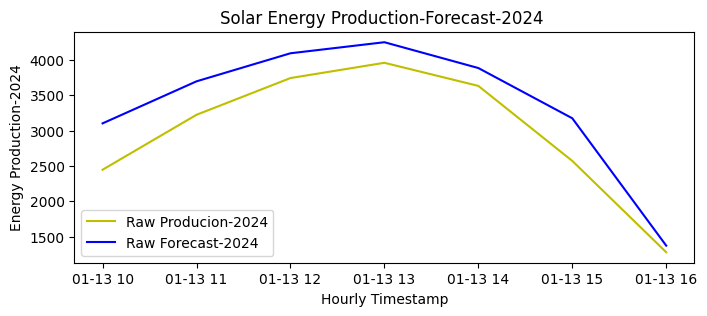

In [85]:
month = 1
day = 13
plt.figure(figsize=(8,3))
plt.plot(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)].index,val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['Production'], color = 'y' , label = 'Raw Producion-2024')
plt.plot(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)].index,val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['forecast_hourly'], color = 'b' , label = 'Raw Forecast-2024')
plt.xlabel('Hourly Timestamp')
plt.ylabel('Energy Production-2024')
plt.title("Solar Energy Production-Forecast-2024 ")
plt.legend(loc='best')
plt.show()

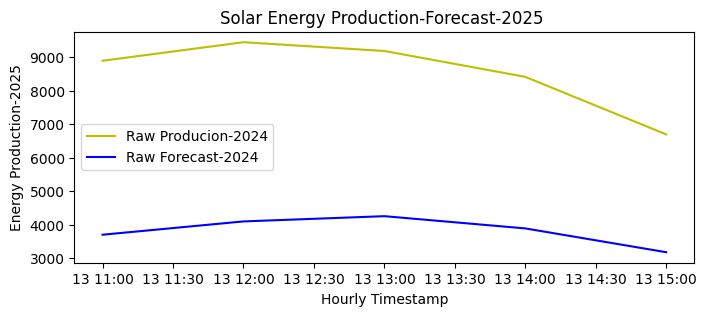

In [86]:
month = 1
day = 13
plt.figure(figsize=(8,3))
plt.plot(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)].index,test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'], color = 'y' , label = 'Raw Producion-2024')
plt.plot(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)].index,test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'], color = 'b' , label = 'Raw Forecast-2024')
plt.xlabel('Hourly Timestamp')
plt.ylabel('Energy Production-2025')
plt.title("Solar Energy Production-Forecast-2025 ")
plt.legend(loc='best')
plt.show()

In [87]:
root_mean_squared_error(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['Production'],val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['forecast_hourly'])

430.91398122345095

In [88]:
root_mean_squared_error(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'],test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'])

4751.690779261215

In [89]:
mean_absolute_percentage_error(val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['Production'],val_hourly[(val_hourly.index.month == month) & (val_hourly.index.day == day)]['forecast_hourly'])

0.13705251907500304

In [90]:
mean_absolute_percentage_error(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'],test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'])

0.5503221443575802

## How much of hourly error is caused purely by daily bias?

In [91]:
actual_sum = daily_val.loc[observed_val_mask, 'Solar_production'].sum()
forecast_sum = daily_val.loc[observed_val_mask, 'forecast'].sum()

print("Actual sum:", actual_sum)
print("Forecast sum:", forecast_sum)
print("Ratio:", forecast_sum / actual_sum)

print("Bias pct recomputed:",
      (forecast_sum - actual_sum) / actual_sum * 100)

Actual sum: 10420592.0
Forecast sum: 10528100.564973576
Ratio: 1.010316934486407
Bias pct recomputed: 1.0316934486406915


In [92]:
bias_ratio_val = (
    daily_val.loc[observed_val_mask, 'forecast'].sum()
    / daily_val.loc[observed_val_mask, 'Solar_production'].sum()
)

print("Validation bias ratio:", bias_ratio_val)

Validation bias ratio: 1.010316934486407


In [93]:
daily_test['forecast_corrected'] = (
    daily_test['forecast'] / bias_ratio_val
)

In [94]:
mape_test_old = mean_absolute_percentage_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast']
)

rmse_test_old = root_mean_squared_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast']
)

bias_test_old = (
    daily_test.loc[observed_test_mask, 'forecast']
    - daily_test.loc[observed_test_mask, 'Solar_production']
).mean()

bias_pct_test_old = (
    bias_test_old
    / daily_test.loc[observed_test_mask, 'Solar_production'].mean()
    * 100
)

print("Corrected Test MAPE:", mape_test_old)
print("Corrected Test RMSE:", rmse_test_old)
print("Corrected Test Bias %:", bias_pct_test_old)

Corrected Test MAPE: 0.3994523365747419
Corrected Test RMSE: 23338.770065226938
Corrected Test Bias %: -14.794729301523613


In [95]:
mape_test_corrected = mean_absolute_percentage_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast_corrected']
)

rmse_test_corrected = root_mean_squared_error(
    daily_test.loc[observed_test_mask, 'Solar_production'],
    daily_test.loc[observed_test_mask, 'forecast_corrected']
)

bias_test_corrected = (
    daily_test.loc[observed_test_mask, 'forecast_corrected']
    - daily_test.loc[observed_test_mask, 'Solar_production']
).mean()

bias_pct_test_corrected = (
    bias_test_corrected
    / daily_test.loc[observed_test_mask, 'Solar_production'].mean()
    * 100
)

print("Corrected Test MAPE:", mape_test_corrected)
print("Corrected Test RMSE:", rmse_test_corrected)
print("Corrected Test Bias %:", bias_pct_test_corrected)

Corrected Test MAPE: 0.3984735273789237
Corrected Test RMSE: 23510.616604568455
Corrected Test Bias %: -15.664809932350229


In [96]:
# # Naya wala 2021-2024
test_hourly_corrected = hourly_mapping(
    df = test ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_test['forecast_corrected'] ,
    production_col = "Production"
)
test_hourly_corrected = test_hourly_corrected[test_hourly_corrected['Production'].notna()]

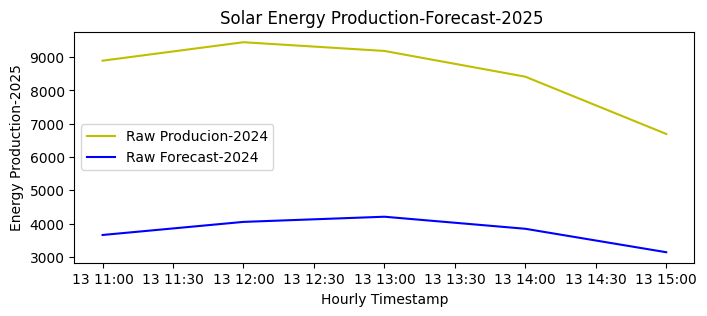

In [97]:
month = 1
day = 13
plt.figure(figsize=(8,3))
plt.plot(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)].index,test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['Production'], color = 'y' , label = 'Raw Producion-2024')
plt.plot(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)].index,test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['forecast_hourly'], color = 'b' , label = 'Raw Forecast-2024')
plt.xlabel('Hourly Timestamp')
plt.ylabel('Energy Production-2025')
plt.title("Solar Energy Production-Forecast-2025 ")
plt.legend(loc='best')
plt.show()

In [98]:
root_mean_squared_error(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['Production'],test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['forecast_hourly'])

4790.76211021018

In [99]:
mean_absolute_percentage_error(test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['Production'],test_hourly_corrected[(test_hourly_corrected.index.month == month) & (test_hourly_corrected.index.day == day)]['forecast_hourly'])

0.5549140667715197

We see a 2% improvement in MAPE and 3% improvement in RMSE

In [100]:
# True 2024 log trend slope
actual_2024_slope = np.log(daily_val['Solar_production']).diff().median()

# Historical slope
historical_slope = daily_stl_res.trend.diff().median()

print(actual_2024_slope, historical_slope)

0.0033484716338172404 0.00016302180418836798


C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



#### Conclusion
This seems model shows a structural drift in year 2025.

Deterministic trend is too rigid.

We needed a model that allows stochastic level movement.

We'll try to move to state-space model which can replace deterministic extrapolation with adaptive state evolution.

In [101]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

In [102]:
y_train = daily_train['ln_Solar_production']

# State-space model: Fit Local Linear Trend + Seasonal

In [103]:
model = UnobservedComponents(
    y_train,
    level='local linear trend',
    freq_seasonal=[{'period': 365, 'harmonics': 5}]
)
res = model.fit()
print(res.summary())

                                Unobserved Components Results                                 
Dep. Variable:                    ln_Solar_production   No. Observations:                 1827
Model:                             local linear trend   Log Likelihood                -643.689
                   + stochastic freq_seasonal(365(5))   AIC                           1295.377
Date:                                Tue, 03 Mar 2026   BIC                           1317.393
Time:                                        19:06:12   HQIC                          1303.501
Sample:                                    01-01-2020                                         
                                         - 12-31-2024                                         
Covariance Type:                                  opg                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [104]:
forecast_res = res.get_forecast(steps=len(daily_test))
log_forecast = forecast_res.predicted_mean
forecast = np.exp(log_forecast)

In [105]:
daily_test['forecast_unobservedmodel'] =forecast

In [106]:
observed_mask = daily_test['Solar_production'] > 0

In [107]:
mape_daily_observed= mean_absolute_percentage_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel'])
mape_daily_observed

0.3718769099910714

In [108]:
mae_daily_observed = mean_absolute_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel'])
mae_daily_observed

15306.844808026242

In [109]:
rmse_daily_observed =  root_mean_squared_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel'])
rmse_daily_observed

18996.411240482284

## Adding AR(1)

In [110]:
model = UnobservedComponents(
    y_train,
    level='local linear trend',
    freq_seasonal=[{'period': 365, 'harmonics': 5}],
    autoregressive=1
)
res = model.fit()
print(res.summary())

                                Unobserved Components Results                                 
Dep. Variable:                    ln_Solar_production   No. Observations:                 1827
Model:                             local linear trend   Log Likelihood                -628.271
                   + stochastic freq_seasonal(365(5))   AIC                           1268.541
                                              + AR(1)   BIC                           1301.564
Date:                                Tue, 03 Mar 2026   HQIC                          1280.726
Time:                                        19:06:18                                         
Sample:                                    01-01-2020                                         
                                         - 12-31-2024                                         
Covariance Type:                                  opg                                         
                                  coef    std err 

In [111]:
forecast_res = res.get_forecast(steps=len(daily_test))
log_forecast = forecast_res.predicted_mean
forecast = np.exp(log_forecast)

In [112]:
daily_test['forecast_unobservedmodel_AR_1'] =forecast

In [113]:
observed_mask = daily_test['Solar_production'] > 0

In [114]:
mape_daily_observed= mean_absolute_percentage_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel_AR_1'])
mape_daily_observed

0.3652945470564259

In [115]:
mae_daily_observed = mean_absolute_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel_AR_1'])
mae_daily_observed

15674.302275413236

In [116]:
rmse_daily_observed =  root_mean_squared_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel_AR_1'])
rmse_daily_observed

19292.377539267123

## Bais Correction

In [117]:
sigma2_irregular = res.params['sigma2.irregular']
forecast_corrected = np.exp(log_forecast + 0.5 * sigma2_irregular)

In [118]:
daily_test['forecast_unobservedmodel_AR_1_cor'] =forecast_corrected

In [119]:
mape_daily_observed= mean_absolute_percentage_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel_AR_1_cor'])
mape_daily_observed

0.37309383705807564

In [120]:
mae_daily_observed = mean_absolute_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel_AR_1_cor'])
mae_daily_observed

15412.548219653809

In [121]:
rmse_daily_observed =  root_mean_squared_error(daily_test.loc[observed_mask]['Solar_production'], daily_test.loc[observed_mask]['forecast_unobservedmodel_AR_1_cor'])
rmse_daily_observed

19144.71932758019

In [122]:
print("2024 mean:", daily_val['Solar_production'].mean())
print("2025 mean:", daily_test['Solar_production'].mean())
print("Percent increase:",
      (daily_test['Solar_production'].mean() /
       daily_val['Solar_production'].mean() - 1) * 100)

2024 mean: 28471.562841530056
2025 mean: 37830.475757575754
Percent increase: 32.87108954340334


This confirms the structural shift from 2020-2024 to 2025. This might be because of capacity expansion/weather/curtailment.

## Lets map this daily forecast to hourly

In [123]:
test_hourly = hourly_mapping(
    df = test ,
    hourly_weights = hourly_weights,
    daily_forecast = daily_test['forecast_unobservedmodel_AR_1_cor'] ,
    production_col = "Production"
)
test_hourly = test_hourly[test_hourly['Production'].notna()]

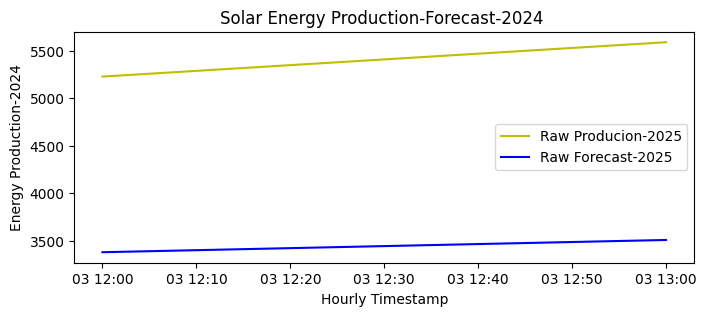

In [124]:
month = 1
day = 3
plt.figure(figsize=(8,3))
plt.plot(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)].index,test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'], color = 'y' , label = 'Raw Producion-2025')
plt.plot(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)].index,test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'], color = 'b' , label = 'Raw Forecast-2025')
plt.xlabel('Hourly Timestamp')
plt.ylabel('Energy Production-2024')
plt.title("Solar Energy Production-Forecast-2024 ")
plt.legend(loc='best')
plt.show()

In [125]:
root_mean_squared_error(test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['Production'],test_hourly[(test_hourly.index.month == month) & (test_hourly.index.day == day)]['forecast_hourly'])

1970.2135033552936

In [126]:
root_mean_squared_error(test_hourly['Production'],test_hourly['forecast_hourly'])

2755.4594580774533

In [127]:
mean_absolute_percentage_error(test_hourly['Production'],test_hourly['forecast_hourly'])

0.29775760854113775

In [128]:
mean_absolute_error(test_hourly['Production'],test_hourly['forecast_hourly'])

2220.5094858741454

In [137]:
smape_val = np.mean(
    2 * np.abs(test_hourly['forecast_hourly'] - test_hourly['Production']) / (np.abs(test_hourly['forecast_hourly']) + np.abs(test_hourly['Production']))
)
smape_val

0.3332645912625601

[]

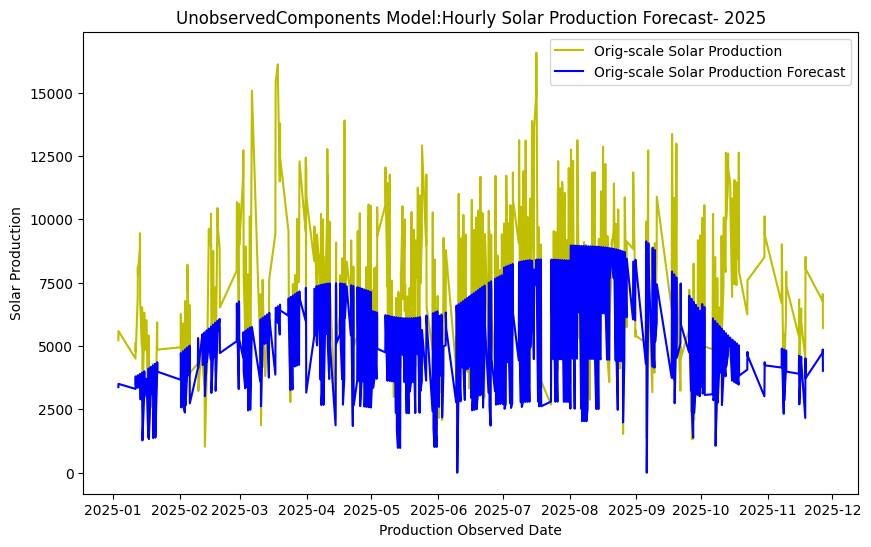

In [138]:
plt.figure(figsize=(10,6))
plt.plot(test_hourly.index, test_hourly['Production'] , color ='y' , label ='Orig-scale Solar Production')
plt.plot(test_hourly.index, test_hourly['forecast_hourly'],  color ='b' , label ='Orig-scale Solar Production Forecast')
plt.xlabel('Production Observed Date')
plt.ylabel('Solar Production')
plt.title('UnobservedComponents Model:Hourly Solar Production Forecast- 2025')
plt.legend(loc= 'best')
plt.plot()

## Some statistical tests

In [129]:
(test_hourly['Production'] / test_hourly['Production'].mean()).corr(
    test_hourly['forecast_hourly'] / test_hourly['forecast_hourly'].mean()
)

0.5328646184191097

In [130]:
test_hourly['Production'].corr(test_hourly['forecast_hourly'])

0.5328646184191097

In [131]:
jan = test_hourly[test_hourly.index.month == 1]
jan['Production'].corr(jan['forecast_hourly'])

0.4818449675412704

In [132]:
daily_test['Solar_production'].corr(daily_test['forecast_unobservedmodel_AR_1'])

0.5094824586827946

Hourly correlation (full 2025) ≈ 0.533

Hourly correlation (Jan 2025 only) ≈ 0.482

Daily correlation (2025) ≈ 0.509

## Let's try to explain reason behind the part model is still not able to predict ( Complete Regime Change) 

## Compare Daily Variance (2024 vs 2025)

In [133]:
import numpy as np

mean_2024 = daily_val['Solar_production'].mean()
mean_2025 = daily_test['Solar_production'].mean()

var_2024 = daily_val['Solar_production'].var()
var_2025 = daily_test['Solar_production'].var()

std_2024 = daily_val['Solar_production'].std()
std_2025 = daily_test['Solar_production'].std()

print("Mean ratio:", mean_2025 / mean_2024)
print("Variance ratio:", var_2025 / var_2024)
print("Std ratio:", std_2025 / std_2024)

Mean ratio: 1.3287108954340334
Variance ratio: 1.3488292172308682
Std ratio: 1.1613910698945762


## Compare Log-Space Variance

In [134]:
log_2024 = np.log(daily_val.loc[daily_val['Solar_production'] > 0, 'Solar_production'])
log_2025 = np.log(daily_test.loc[daily_test['Solar_production'] > 0, 'Solar_production'])

log_var_2024 = log_2024.var()
log_var_2025 = log_2025.var()

print("Log variance 2024:", log_var_2024)
print("Log variance 2025:", log_var_2025)
print("Log variance ratio:", log_var_2025 / log_var_2024)

Log variance 2024: 0.2752295770629638
Log variance 2025: 0.2499158990793976
Log variance ratio: 0.9080270432644117


## Formal Variance Equality Test (Levene)

In [135]:
from scipy.stats import levene

stat, p = levene(
    daily_val['Solar_production'],
    daily_test['Solar_production']
)

print("Levene p-value:", p)

Levene p-value: 0.00014711762829478092


p-value ≈ 0.000147

Strong rejection of equal variance.

So variance shift is statistically significant.

## Coefficient of Variation (Scale-Normalized)

In [136]:
cv_2024 = std_2024 / mean_2024
cv_2025 = std_2025 / mean_2025

print("CV 2024:", cv_2024)
print("CV 2025:", cv_2025)

CV 2024: 1.0221518267376752
CV 2025: 0.8934358916819021


## Conclusion

Relative volatility decreased in 2025.

Mean increased 33%

Variance increased only 35%

Relative variability decreased

The distribution became more stable relative to its mean.

#### Model	                   Test Daily MAPE    RMSE
     STL + ARIMA	             ~55%
     UCM (local linear trend)    ~37%
     UCM + AR(1)	             ~36%

Switching to state-space model reduced error by ~34%.

#### Hourly Forecast Evaluation
RMSE: 2755W

MAE: 2220W

MAPE: 29.8%

SMAPE: 33%

Correlation: ~0.53